In [1]:
# !pip install pandas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("small-price-prediction.csv")
dataset

,plot_size,plot_price
0,120,550
1,145,645
2,160,700
3,110,475
4,180,825
5,100,450
6,190,875
7,155,665
8,130,590
9,200,925


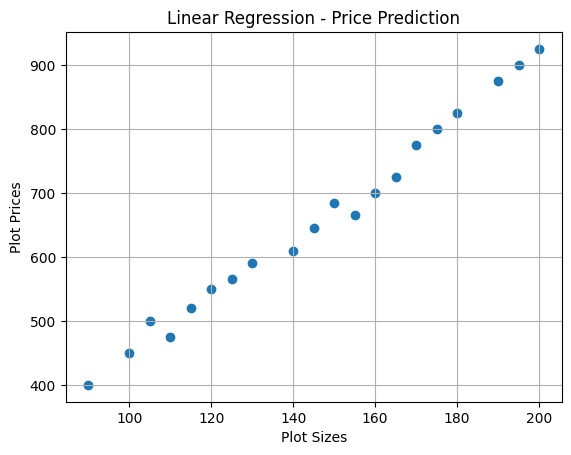

In [3]:
plt.scatter(dataset["plot_size"], dataset["plot_price"])
plt.xlabel("Plot Sizes")
plt.ylabel("Plot Prices")
plt.title("Linear Regression - Price Prediction")
plt.grid(True)
plt.show()

In [4]:
def plot_line(m, data, c):
    plt.scatter(data["plot_size"], data["plot_price"])

    x_min = data["plot_size"].min()
    x_max = data["plot_size"].max()

    y_min = m * x_min + c
    y_max = m * x_max + c

    plt.plot([x_min, x_max], [y_min, y_max], color='red', label=f'y={m:.2f}x + {c:.2f}')
    plt.xlabel("Plot Sizes")
    plt.ylabel("Plot Prices")
    plt.title("Linear Regression - Price Prediction")
    plt.legend()
    plt.show()

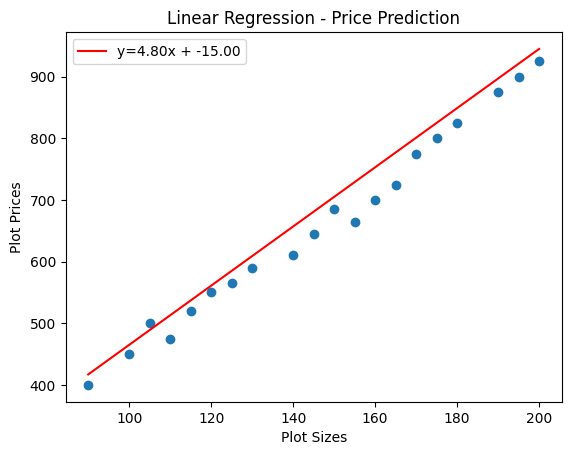

In [5]:
plot_line(4.8, dataset, -15)

In [14]:
# Function to calculate the loss
def calculate_loss(m, data, c):
    total_loss = 0
    for serial in range(0, len(dataset)):
        x = data.iloc[serial]["plot_size"]   # 120, 145, 160, 110 ....
        y = data.iloc[serial]["plot_price"]  # 150, ......
        prediction = m * x + c
        error = (y - prediction)**2
        total_loss = total_loss + error;
    final_loss = total_loss / len(dataset)
    return final_loss

In [16]:
print(f"m={-10}, c={-10}, loss={calculate_loss(-10, dataset, -10)}")
print(f"m={0}, c={0}, loss={calculate_loss(0, dataset, 0)}")
print(f"m={10}, c={10}, loss={calculate_loss(10, dataset, 10)}")
print(f"m={4.8}, c={-15}, loss={calculate_loss(4.8, dataset, -15)}")

m=-10, c=-10, loss=4759032.5
m=0, c=0, loss=457302.5
m=10, c=10, loss=688172.5
m=4.8, c=-15, loss=998.3


In [17]:
def derivatives(m, c, data, lr):
    m_grad = 0
    b_grad = 0
    N = len(data)

    for i in range(N):
        x = data.iloc[i]['plot_size']
        y = data.iloc[i]['plot_price']
        
        prediction = m * x + c
        error = y - prediction

        m_grad += -2 * x * error  # partial derivative w.r.t m
        b_grad += -2 * error      # partial derivative w.r.t b
    
    m = m - (lr * m_grad / N)    # update m
    c = c - (lr * b_grad / N)    # update b
    
    return m, c

Before training: m = 0, c = 0, Loss = 457302.50
During training: m = 0.20222500000000002, c = 0.001318, Loss = 417320.71


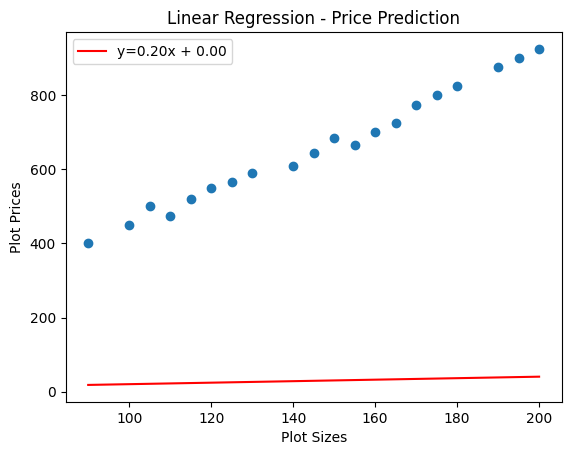

During training: m = 2.791366817524717, c = 0.01817944204977714, Loss = 67110.17


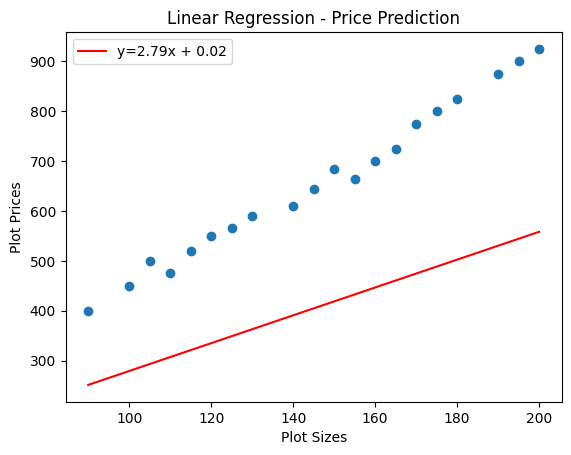

During training: m = 3.82786948864779, c = 0.024907411088602636, Loss = 10984.93


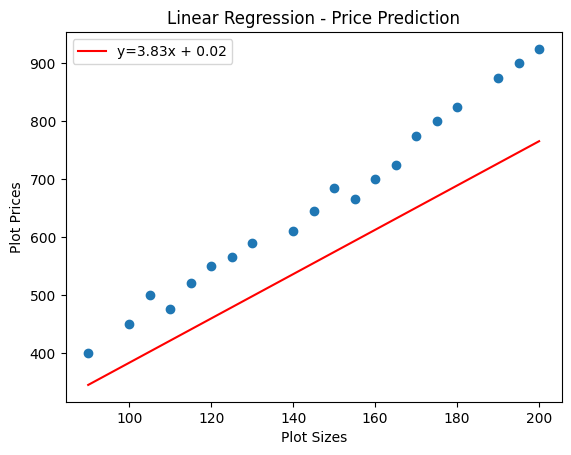

During training: m = 4.242809297693451, c = 0.02757868064425911, Loss = 1990.21


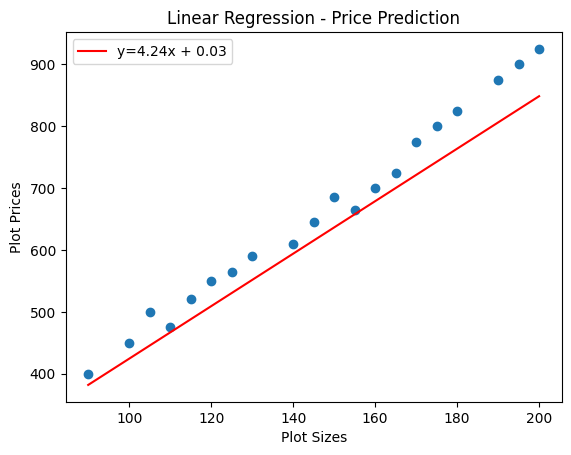

During training: m = 4.408920914812165, c = 0.028625945238765244, Loss = 548.71


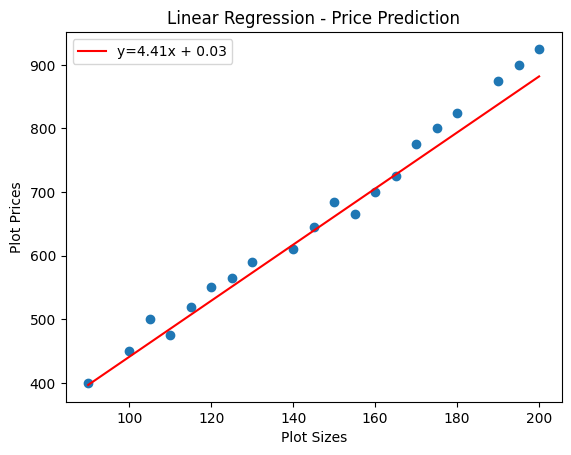

During training: m = 4.475419969991773, c = 0.02902307737377059, Loss = 317.69


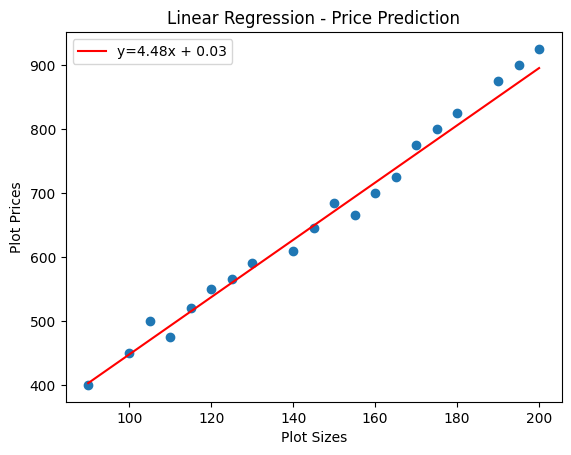

During training: m = 4.5020414597746665, c = 0.02915994418667554, Loss = 280.67


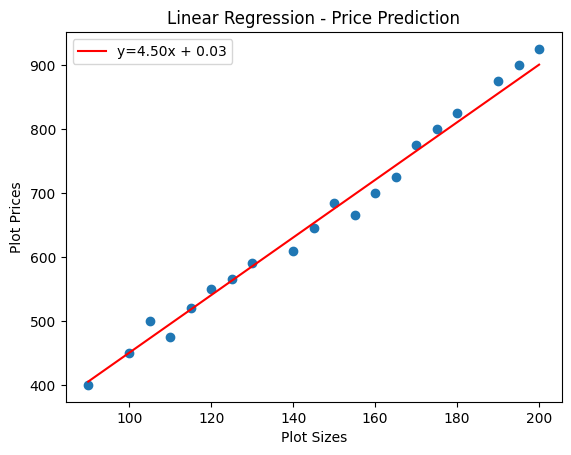

During training: m = 4.512698896520179, c = 0.029192619891062758, Loss = 274.73


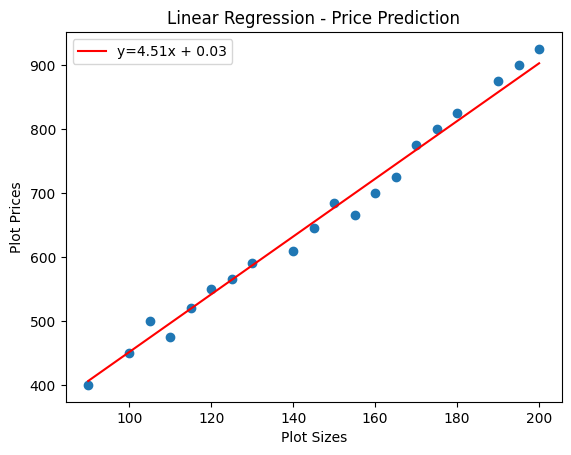

During training: m = 4.516965497043581, c = 0.029183585157418736, Loss = 273.78


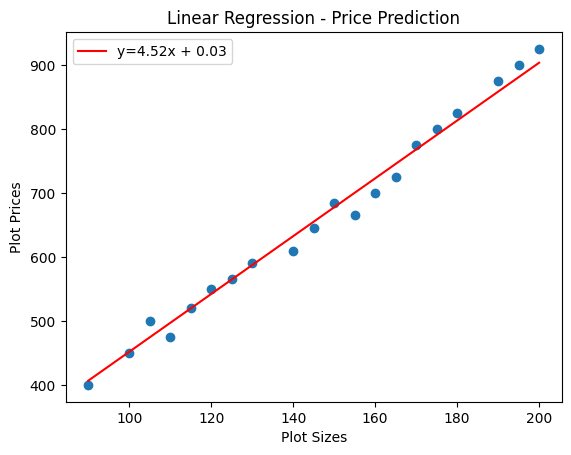

During training: m = 4.5186736753715175, c = 0.02915785266461477, Loss = 273.63


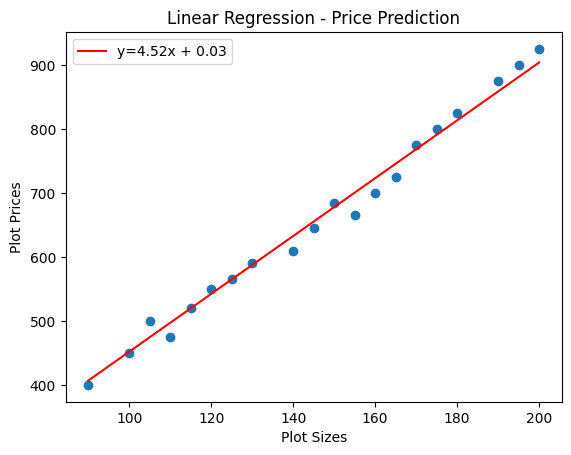

During training: m = 4.519357649056462, c = 0.029125435655137623, Loss = 273.61


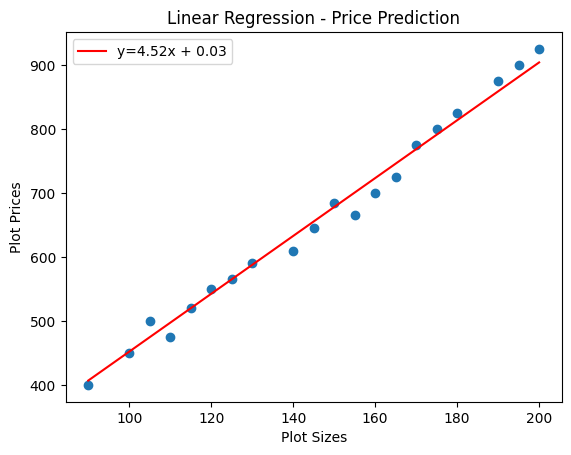

During training: m = 4.519631606305101, c = 0.02909034269702644, Loss = 273.60


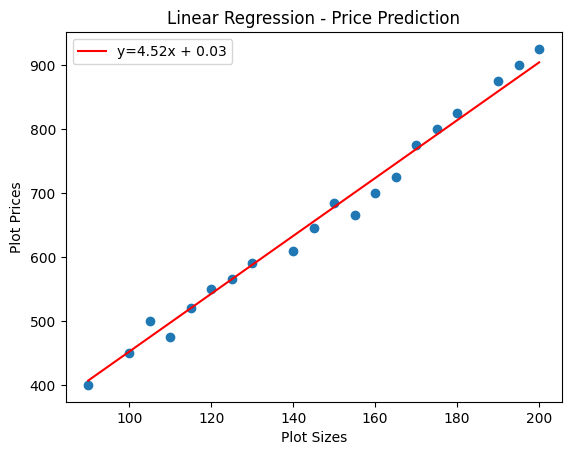

During training: m = 4.519741423038113, c = 0.02905417852698321, Loss = 273.60


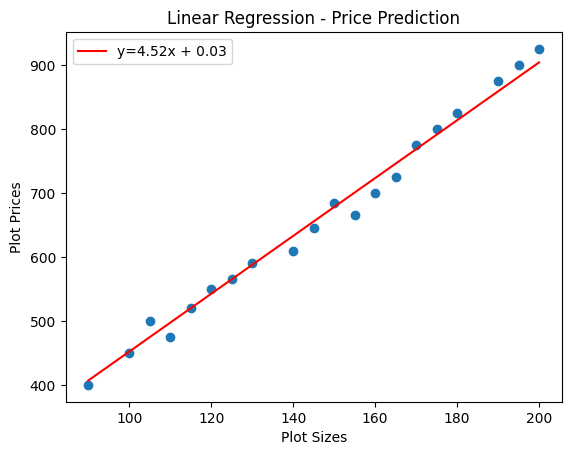

During training: m = 4.519785529944518, c = 0.029017585563910927, Loss = 273.60


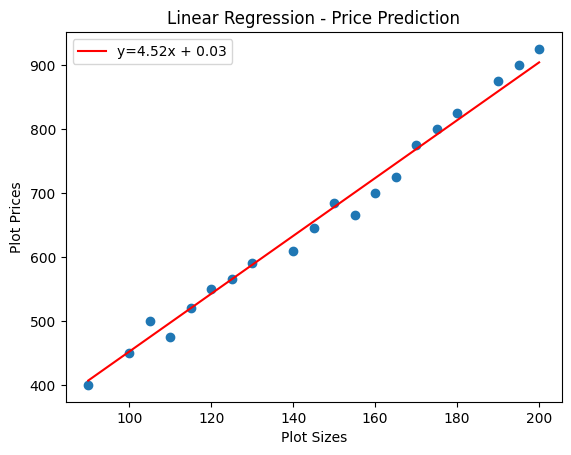

During training: m = 4.519803331454455, c = 0.02898082098523093, Loss = 273.60


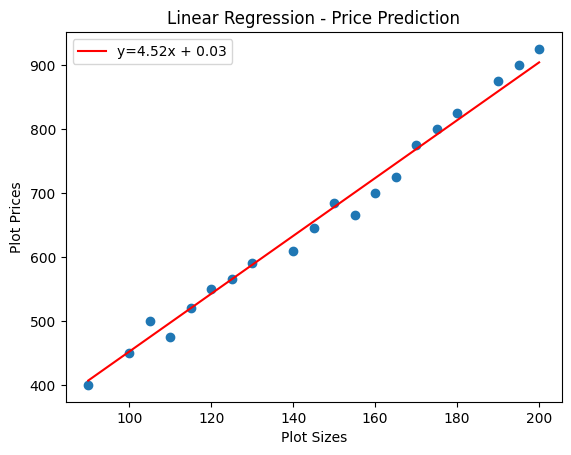

In [30]:
# Hyperparameters
m           = 0
c           = 0
lr          = 0.000001
epochs      = 300

print(f"Before training: m = {m}, c = {c}, Loss = {calculate_loss(m, dataset, c):.2f}")
for epoch in range(epochs):
    m, c = derivatives(m, c, dataset, lr)
    loss = calculate_loss(m, dataset, c)
    if epoch%20 == 0:    
        print(f"During training: m = {m}, c = {c}, Loss = {calculate_loss(m, dataset, c):.2f}")
        plot_line(m, dataset, c)

In [32]:
x = int(input("Enter the size of a plot"))
prediction = m * x + c
print("The ideal price for your plot is:", prediction)

The ideal price for your plot is: 632.8023976813461
